# Dubizzle Egypt — Real Estate Market Analysis

This notebook loads scraped listings from `data/dubizzle.db` and explores the Egyptian property market through a series of visualizations.

**Data source:** https://www.dubizzle.com.eg/en/properties/  
**Database:** SQLite — tables `listings`, `listing_images`, `listing_amenities`

In [2]:
#!pip install numpy pandas matplotlib seaborn
import sqlite3
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

DB_PATH = 'data/dubizzle.db'

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [3]:
con = sqlite3.connect(DB_PATH)

df = pd.read_sql_query('SELECT * FROM listings', con)
images_df = pd.read_sql_query(
    'SELECT listing_id, COUNT(*) AS image_count FROM listing_images GROUP BY listing_id', con
)
amenities_df = pd.read_sql_query('SELECT listing_id, amenity FROM listing_amenities', con)

con.close()

print(f'Listings  : {len(df):,}')
print(f'Columns   : {list(df.columns)}')
df.head(3)

Listings  : 784
Columns   : ['id', 'url', 'title', 'description', 'price', 'price_currency', 'price_period', 'down_payment', 'is_negotiable', 'property_type', 'listing_type', 'area_sqm', 'bedrooms', 'bathrooms', 'floor_number', 'total_floors', 'furnished', 'country', 'governorate', 'city', 'compound', 'full_location', 'seller_name', 'seller_type', 'seller_verified', 'member_since', 'seller_profile_url', 'ad_tier', 'posted_at', 'scraped_at', 'extra_attributes']


,id,url,title,description,price,price_currency,price_period,down_payment,is_negotiable,property_type,...,full_location,seller_name,seller_type,seller_verified,member_since,seller_profile_url,ad_tier,posted_at,scraped_at,extra_attributes
0,503232662,https://www.dubizzle.com.eg/en/ad/%D8%B4%D9%82...,شقه للبيع علي البحر مباشرة في مرسي مطروح,None,2.280000e+12,EGP,NaN,None,0,Property,...,"Marsa Matrouh, Matruh",None,None,0,None,None,elite,1 day ago,2026-03-09T03:46:37.431Z,None
1,503152951,https://www.dubizzle.com.eg/en/ad/townhouse-co...,Townhouse Corner in Mostakbl city Very prime L...,None,1.100000e+07,EGP,NaN,None,0,Townhouse,...,"Green Square, Mostakbal City",None,None,1,None,None,elite,4 days ago,2026-03-09T03:46:37.433Z,None
2,502757166,https://www.dubizzle.com.eg/en/ad/the-best-dea...,THE BEST DEAL VILLA FOR SALE IN MADINATY,None,2.100000e+07,EGP,NaN,None,0,Villa,...,"Madinaty, Cairo",None,None,0,None,None,elite,1 week ago,2026-03-09T03:58:39.824Z,None


## 2. Clean & Engineer Features

In [4]:
# parse posted_at -> days_ago
def parse_days_ago(s):
    """Convert strings like '3 days ago', '1 week ago', '2 months ago' to int days."""
    if pd.isna(s):
        return np.nan
    s = s.lower().strip()
    m = re.match(r'(\d+)\s+(day|week|month|year)', s)
    if not m:
        return 0  # 'today' / 'just now'
    n, unit = int(m.group(1)), m.group(2)
    return n * {'day': 1, 'week': 7, 'month': 30, 'year': 365}[unit]

df['days_ago'] = df['posted_at'].apply(parse_days_ago)

# price per sqm
df['price_per_sqm'] = df['price'] / df['area_sqm']

# boolean columns
df['is_negotiable'] = df['is_negotiable'].astype(bool)
df['seller_verified'] = df['seller_verified'].astype(bool)

# merge image counts
df = df.merge(images_df, left_on='id', right_on='listing_id', how='left')
df['image_count'] = df['image_count'].fillna(0).astype(int)

# IQR bounds helper
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Hard cap first: prices above these thresholds are concatenation artefacts
# from the card-level scraper (two numbers joined together).
# Then apply IQR filtering within each listing_type for the remaining tail.
HARD_CAP = {'for_sale': 500_000_000, 'for_rent': 2_000_000}

clean_parts = []
for lt, grp in df.groupby('listing_type'):
    cap = HARD_CAP.get(lt, float('inf'))
    grp = grp[grp['price'].isna() | (grp['price'] <= cap)]
    lo, hi = iqr_bounds(grp['price'].dropna())
    mask = grp['price'].between(lo, hi)
    clean_parts.append(grp[mask | grp['price'].isna()])

dfc = pd.concat(clean_parts).reset_index(drop=True)

removed = len(df) - len(dfc)
print(f'Rows after outlier removal: {len(dfc):,}  (removed {removed} outliers)')
print(dfc[['price', 'area_sqm', 'price_per_sqm', 'days_ago']].describe().round(1))

Rows after outlier removal: 544  (removed 240 outliers)
            price  area_sqm  price_per_sqm  days_ago
count       544.0     544.0          544.0     544.0
mean    7120300.2     198.1        34931.4       2.5
std     8883659.4     204.6        38031.5       4.8
min         300.0      30.0            3.0       0.0
25%       55000.0     130.0          328.6       0.0
50%     4525000.0     164.0        30690.5       0.0
75%    10275000.0     220.0        55317.5       4.0
max    45000000.0    4100.0       294117.6      60.0


## 3. Overview Stats

/var/folders/pv/4m91l3q131g6dgr6grvwsv5w0000gn/T/ipykernel_37641/2946680695.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_counts.index, y=tier_counts.values, ax=axes[1], palette='Blues_d')
/var/folders/pv/4m91l3q131g6dgr6grvwsv5w0000gn/T/ipykernel_37641/2946680695.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=st_counts.index, y=st_counts.values, ax=axes[2], palette='Greens_d')


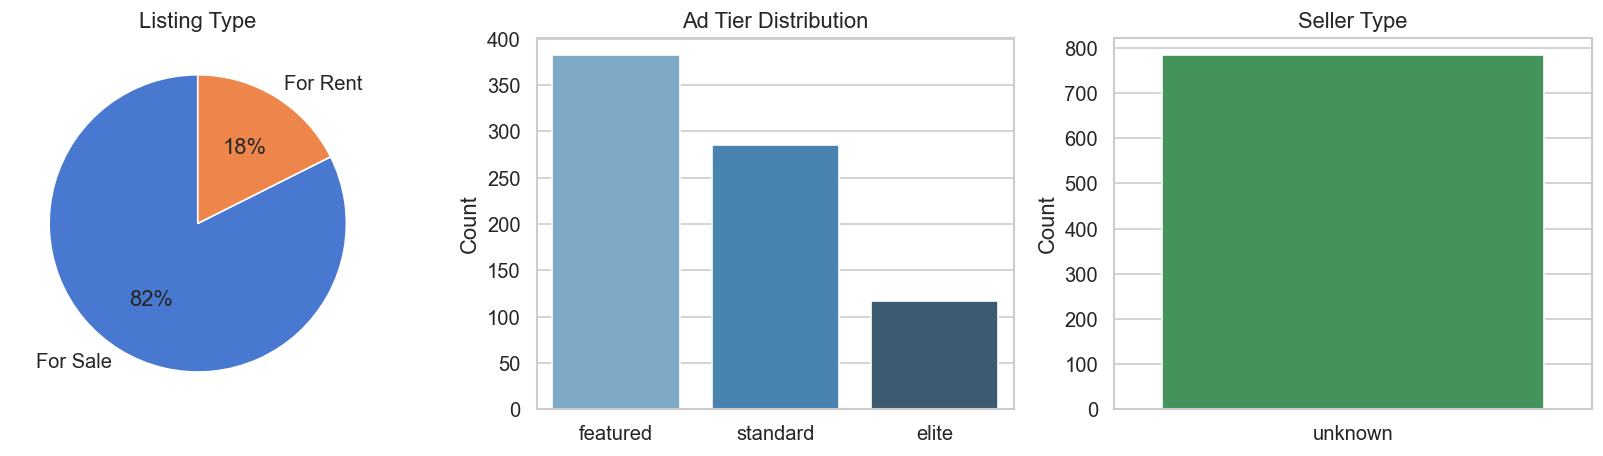

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Listing type
lt_counts = df['listing_type'].value_counts()
axes[0].pie(
    lt_counts,
    labels=[l.replace('_', ' ').title() for l in lt_counts.index],
    autopct='%1.0f%%',
    startangle=90,
    colors=sns.color_palette('muted', len(lt_counts))
)
axes[0].set_title('Listing Type')

# Ad tier
tier_counts = df['ad_tier'].fillna('unknown').value_counts()
sns.barplot(x=tier_counts.index, y=tier_counts.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Ad Tier Distribution')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

# Seller type
st_counts = df['seller_type'].fillna('unknown').value_counts()
sns.barplot(x=st_counts.index, y=st_counts.values, ax=axes[2], palette='Greens_d')
axes[2].set_title('Seller Type')
axes[2].set_xlabel('')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('overview_stats.png', bbox_inches='tight')
plt.show()

## 4. Property Type Breakdown

/var/folders/pv/4m91l3q131g6dgr6grvwsv5w0000gn/T/ipykernel_37641/3477592597.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pt.values, y=pt.index, ax=ax, palette='viridis')


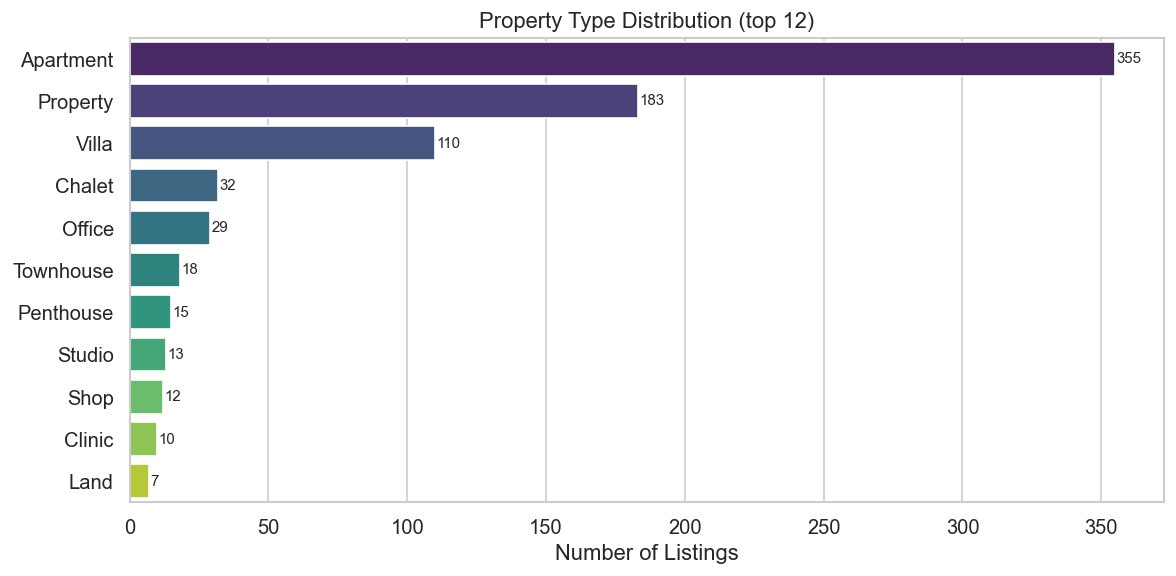

In [6]:
pt = df['property_type'].fillna('Unknown').value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=pt.values, y=pt.index, ax=ax, palette='viridis')
ax.set_title('Property Type Distribution (top 12)')
ax.set_xlabel('Number of Listings')
ax.set_ylabel('')
for i, v in enumerate(pt.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('property_types.png', bbox_inches='tight')
plt.show()

## 5. Price Distributions — For Sale vs For Rent

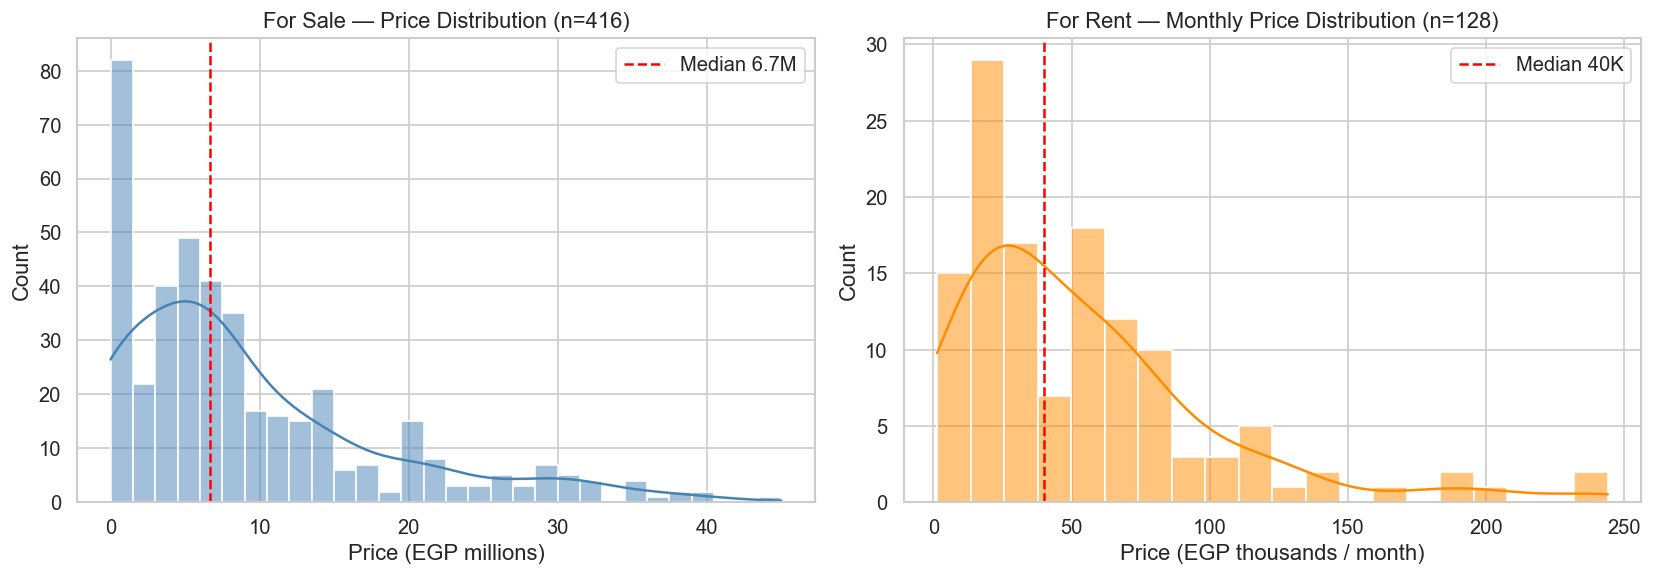

In [7]:
sale = dfc[dfc['listing_type'] == 'for_sale']['price'].dropna()
rent = dfc[dfc['listing_type'] == 'for_rent']['price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For Sale
sns.histplot(sale / 1e6, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'For Sale — Price Distribution (n={len(sale):,})')
axes[0].set_xlabel('Price (EGP millions)')
axes[0].set_ylabel('Count')
axes[0].axvline(sale.median() / 1e6, color='red', ls='--', lw=1.5,
                label=f'Median {sale.median()/1e6:.1f}M')
axes[0].legend()

# For Rent
sns.histplot(rent / 1e3, bins=20, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f'For Rent — Monthly Price Distribution (n={len(rent):,})')
axes[1].set_xlabel('Price (EGP thousands / month)')
axes[1].set_ylabel('Count')
axes[1].axvline(rent.median() / 1e3, color='red', ls='--', lw=1.5,
                label=f'Median {rent.median()/1e3:.0f}K')
axes[1].legend()

plt.tight_layout()
plt.savefig('price_distributions.png', bbox_inches='tight')
plt.show()

## 6. Median Sale Price by City (Top 12)

In [ ]:
city_price = (
    dfc[dfc['listing_type'] == 'for_sale']
    .groupby('city')['price']
    .agg(['median', 'count'])
    .query('count >= 3')
    .sort_values('median', ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=city_price, y='city', x='median', palette='rocket_r', ax=ax)
ax.set_title('Median Sale Price by City (min 3 listings)')
ax.set_xlabel('Median Price (EGP)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, row in city_price.iterrows():
    ax.text(row['median'] + city_price['median'].max() * 0.01, i,
            f"n={int(row['count'])}", va='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('city_median_price.png', bbox_inches='tight')
plt.show()

## 7. Price vs Area Scatter (For Sale)

In [ ]:
scatter_df = (
    dfc[
        (dfc['listing_type'] == 'for_sale') &
        dfc['price'].notna() &
        dfc['area_sqm'].notna() &
        (dfc['area_sqm'] < 2000) &
        dfc['property_type'].notna()
    ]
    .copy()
)

top_types = scatter_df['property_type'].value_counts().head(5).index.tolist()
scatter_df = scatter_df[scatter_df['property_type'].isin(top_types)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=scatter_df, x='area_sqm', y='price',
    hue='property_type', alpha=0.65, s=60, palette='tab10', ax=ax
)
ax.set_title('Price vs Area — For Sale (top 5 property types)')
ax.set_xlabel('Area (m\u00b2)')
ax.set_ylabel('Price (EGP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(title='Property Type', loc='upper left')
plt.tight_layout()
plt.savefig('price_vs_area.png', bbox_inches='tight')
plt.show()

## 8. Bedroom Count Distribution

In [ ]:
bed_df = df[df['bedrooms'].between(0, 8)].copy()

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(
    data=bed_df, x='bedrooms', hue='listing_type',
    palette={'for_sale': 'steelblue', 'for_rent': 'darkorange'}, ax=ax
)
ax.set_title('Bedroom Count Distribution')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Count')
ax.legend(title='Listing Type', labels=['For Sale', 'For Rent'])
plt.tight_layout()
plt.savefig('bedroom_distribution.png', bbox_inches='tight')
plt.show()

## 9. Price per m\u00b2 by City (For Sale)

In [ ]:
ppsqm = (
    dfc[
        (dfc['listing_type'] == 'for_sale') &
        dfc['price_per_sqm'].notna() &
        dfc['city'].notna()
    ]
    .groupby('city')['price_per_sqm']
    .agg(['median', 'count'])
    .query('count >= 3')
    .sort_values('median', ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=ppsqm, y='city', x='median', palette='magma_r', ax=ax)
ax.set_title('Median Price per m\u00b2 by City (For Sale, min 3 listings)')
ax.set_xlabel('Median EGP / m\u00b2')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for i, row in ppsqm.iterrows():
    ax.text(row['median'] + ppsqm['median'].max() * 0.01, i,
            f"n={int(row['count'])}", va='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('price_per_sqm_city.png', bbox_inches='tight')
plt.show()

## 10. Listing Age — How Fresh Is The Data?

In [ ]:
days_df = df[df['days_ago'].notna() & (df['days_ago'] <= 180)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(days_df['days_ago'], bins=30, kde=True, color='teal', ax=ax)
ax.set_title('Listing Age at Time of Scrape (days since posted)')
ax.set_xlabel('Days Ago')
ax.set_ylabel('Count')
ax.axvline(days_df['days_ago'].median(), color='red', ls='--', lw=1.5,
           label=f"Median {days_df['days_ago'].median():.0f} days")
ax.legend()
plt.tight_layout()
plt.savefig('listing_age.png', bbox_inches='tight')
plt.show()

## 11. Furnished Status by Property Type

In [ ]:
furn_df = df[
    df['furnished'].notna() &
    df['property_type'].isin(['Apartment', 'Villa', 'Townhouse', 'Studio'])
]

if len(furn_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(
        data=furn_df, x='property_type', hue='furnished', palette='Set2', ax=ax
    )
    ax.set_title('Furnished Status by Property Type')
    ax.set_xlabel('Property Type')
    ax.set_ylabel('Count')
    ax.legend(title='Furnished Status')
    plt.tight_layout()
    plt.savefig('furnished_status.png', bbox_inches='tight')
    plt.show()
else:
    print('No furnished data available. Run scraper with --detail flag to collect it.')

## 12. Top Amenities

In [ ]:
if len(amenities_df) > 0:
    top_amenities = amenities_df['amenity'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=top_amenities.values, y=top_amenities.index, palette='crest', ax=ax)
    ax.set_title('Top 15 Most Common Amenities')
    ax.set_xlabel('Number of Listings')
    ax.set_ylabel('')
    for i, v in enumerate(top_amenities.values):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('top_amenities.png', bbox_inches='tight')
    plt.show()
else:
    print('No amenities data. Run the scraper with --detail flag to collect it.')

## 13. Image Count vs Price (Do more photos indicate higher price?)

In [ ]:
img_price = dfc[
    (dfc['listing_type'] == 'for_sale') &
    dfc['price'].notna() &
    (dfc['image_count'] > 0)
].copy()

if len(img_price) > 0:
    img_price['image_count_bin'] = pd.cut(
        img_price['image_count'],
        bins=[0, 2, 5, 10, 20, 100],
        labels=['1-2', '3-5', '6-10', '11-20', '20+']
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=img_price, x='image_count_bin', y='price',
        palette='coolwarm', ax=ax,
        order=['1-2', '3-5', '6-10', '11-20', '20+']
    )
    ax.set_title('Sale Price by Number of Photos')
    ax.set_xlabel('Image Count')
    ax.set_ylabel('Price (EGP)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    plt.tight_layout()
    plt.savefig('price_by_image_count.png', bbox_inches='tight')
    plt.show()
else:
    print('No image count data. Run the scraper with --detail flag to collect it.')

## 14. Summary Table

In [ ]:
summary = (
    dfc[dfc['price'].notna()]
    .groupby('listing_type')
    .agg(
        count=('id', 'count'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max'),
        median_area_sqm=('area_sqm', 'median'),
        median_bedrooms=('bedrooms', 'median'),
    )
    .reset_index()
)

for col in ['median_price', 'mean_price', 'min_price', 'max_price']:
    summary[col] = summary[col].apply(lambda x: f'EGP {x:,.0f}')

summary